# Laptop Price Prediction Project
This notebook aims to build a machine learning model to predict laptop prices based on various specifications.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/laptop (3).csv'
df = pd.read_csv(file_path, encoding='latin-1')

# Display basic info and the first few rows
print("Dataset Info:")
display(df.info())
print("\nFirst 5 rows:")
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      1303 non-null   int64  
 1   Unnamed: 0        1273 non-null   float64
 2   Company           1273 non-null   object 
 3   TypeName          1273 non-null   object 
 4   Inches            1273 non-null   object 
 5   ScreenResolution  1273 non-null   object 
 6   Cpu               1273 non-null   object 
 7   Ram               1273 non-null   object 
 8   Memory            1273 non-null   object 
 9   Gpu               1273 non-null   object 
 10  OpSys             1273 non-null   object 
 11  Weight            1273 non-null   object 
 12  Price             1273 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


None


First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## Initial Data Exploration
Let's visualize the distribution of the target variable (Price) to identify any skewness or outliers.

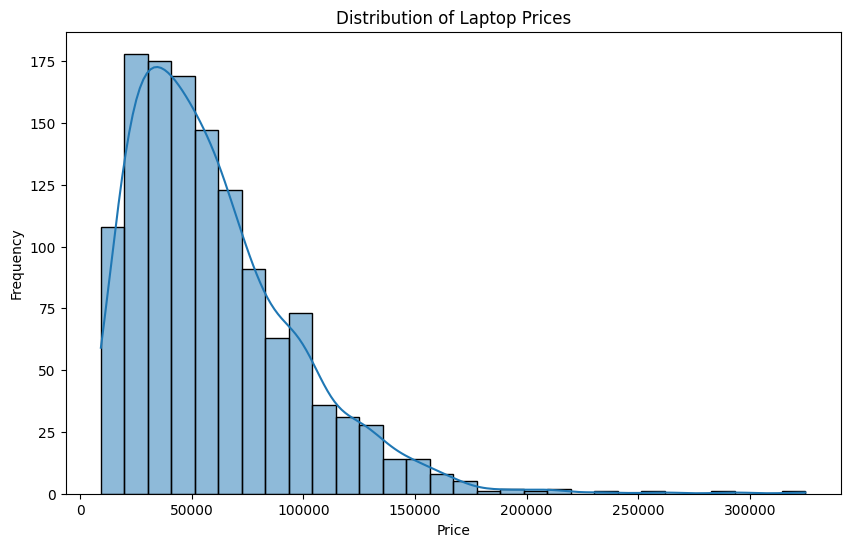

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

## Data Preprocessing
In this step, we will handle missing values and clean numerical columns that are currently stored as strings (like Ram and Weight).

In [5]:
import numpy as np

# 1. Create a copy and handle basic missing values
df_cleaned = df.dropna(subset=['Company', 'Price']).copy()

# 2. Clean 'Ram' column
df_cleaned['Ram'] = df_cleaned['Ram'].str.replace('GB', '', regex=False).astype(int)

# 3. Clean 'Weight' column: replace '?' with NaN, remove 'kg', convert to float
df_cleaned['Weight'] = df_cleaned['Weight'].replace('?', np.nan)
df_cleaned['Weight'] = df_cleaned['Weight'].str.replace('kg', '', regex=False).astype(float)

# 4. Clean 'Inches' column: replace '?' with NaN and convert to float
df_cleaned['Inches'] = df_cleaned['Inches'].replace('?', np.nan).astype(float)

# 5. Drop any newly created NaNs from the cleaning process
df_cleaned = df_cleaned.dropna()

# 6. Remove unnecessary columns
df_cleaned = df_cleaned.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

print("Cleaned Data Info:")
display(df_cleaned.info())
display(df_cleaned.head())

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1271 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1271 non-null   object 
 1   TypeName          1271 non-null   object 
 2   Inches            1271 non-null   float64
 3   ScreenResolution  1271 non-null   object 
 4   Cpu               1271 non-null   object 
 5   Ram               1271 non-null   int64  
 6   Memory            1271 non-null   object 
 7   Gpu               1271 non-null   object 
 8   OpSys             1271 non-null   object 
 9   Weight            1271 non-null   float64
 10  Price             1271 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 119.2+ KB


None

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


## Feature Engineering
We will extract technical specs from text columns to help the model understand the hardware differences.

In [6]:
# Extract Touchscreen and IPS information
df_cleaned['Touchscreen'] = df_cleaned['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df_cleaned['IPS'] = df_cleaned['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# Extract CPU Brand
def fetch_cpu(text):
    cpu_name = " ".join(text.split()[0:3])
    if cpu_name == 'Intel Core i7' or cpu_name == 'Intel Core i5' or cpu_name == 'Intel Core i3':
        return cpu_name
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

df_cleaned['Cpu_brand'] = df_cleaned['Cpu'].apply(fetch_cpu)

# Simplify Memory into SSD/HDD (basic check)
df_cleaned['SSD'] = df_cleaned['Memory'].apply(lambda x: 1 if 'SSD' in x else 0)
df_cleaned['HDD'] = df_cleaned['Memory'].apply(lambda x: 1 if 'HDD' in x else 0)

print("Features Engineered. Previewing new columns:")
display(df_cleaned[['Touchscreen', 'IPS', 'Cpu_brand', 'SSD', 'HDD']].head())

Features Engineered. Previewing new columns:


,Touchscreen,IPS,Cpu_brand,SSD,HDD
0,0,1,Intel Core i5,1,0
1,0,0,Intel Core i5,0,0
2,0,0,Intel Core i5,1,0
3,0,1,Intel Core i7,1,0
4,0,1,Intel Core i5,1,0


## Model Development
We will now prepare the data for training by encoding categorical variables and then evaluate different machine learning algorithms.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Define features and target
X = df_cleaned.drop(columns=['Price', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu'])
y = df_cleaned['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)

# Get indices of categorical columns for the transformer
cat_cols = ['Company', 'TypeName', 'OpSys', 'Cpu_brand']
cat_indices = [X.columns.get_loc(col) for col in cat_cols]

# Define the preprocessing
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), cat_indices)
], remainder='passthrough')

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=3),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=3)
}

for name, model in models.items():
    pipe = Pipeline([
        ('step1', step1),
        ('step2', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name}:")
    print(f"R2 score: {r2_score(y_test, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}\n")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Linear Regression:
R2 score: 0.5778
MAE: 14807.0984



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest:
R2 score: 0.7416
MAE: 10324.2598

Gradient Boosting:
R2 score: 0.7382
MAE: 11644.2574



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Interpretability and Insights
Using the Random Forest model (which typically performs well on this type of data), we can visualize which features are most influential in determining the price.

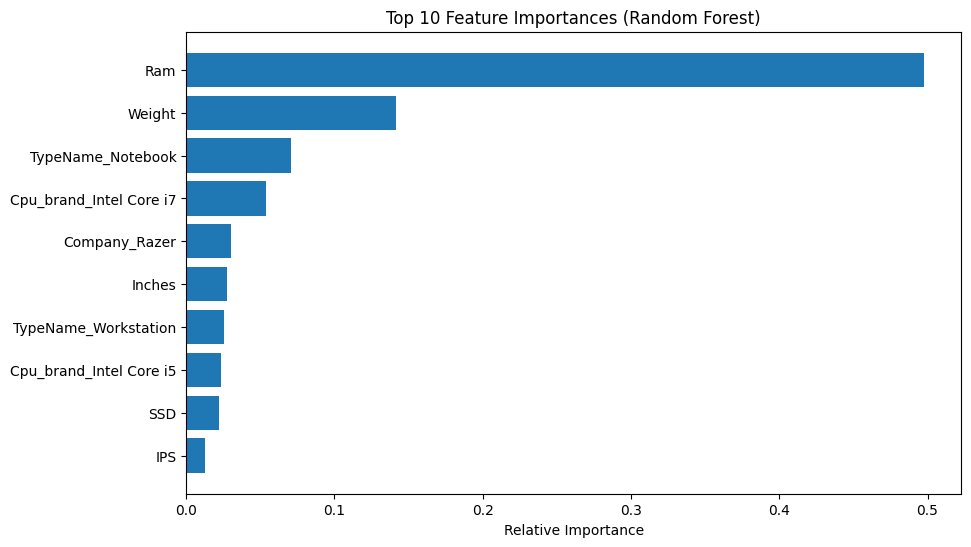

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Re-fit the Random Forest pipeline specifically to extract importances
rf_pipe = Pipeline([
    ('step1', step1),
    ('step2', RandomForestRegressor(n_estimators=100, random_state=3))
])
rf_pipe.fit(X_train, y_train)

# Get feature names after one-hot encoding
encoded_cat_names = rf_pipe.named_steps['step1'].transformers_[0][1].get_feature_names_out(cat_cols)
other_cols = [X.columns[i] for i in range(len(X.columns)) if i not in cat_indices]
feature_names = np.concatenate([encoded_cat_names, other_cols])

# Get importances
importances = rf_pipe.named_steps['step2'].feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Model Development
We will now prepare the data for training by encoding categorical variables and then evaluate different machine learning algorithms.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Define features and target
X = df_cleaned.drop(columns=['Price', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu'])
y = df_cleaned['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)

# Dynamically get indices for categorical columns to avoid structure errors
cat_cols = ['Company', 'TypeName', 'OpSys', 'Cpu_brand']
cat_indices = [X.columns.get_loc(col) for col in cat_cols]

# Define the preprocessing
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), cat_indices)
], remainder='passthrough')

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=3),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=3)
}

for name, model in models.items():
    pipe = Pipeline([
        ('step1', step1),
        ('step2', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name}:")
    print(f"R2 score: {r2_score(y_test, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}\n")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Linear Regression:
R2 score: 0.5778
MAE: 14807.0984



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest:
R2 score: 0.7416
MAE: 10324.2598

Gradient Boosting:
R2 score: 0.7382
MAE: 11644.2574

